# 🌿 GreenAudit – Campus Sustainability & Carbon Tracker
### Complete AI + Optimization System

**Objective:** Monitor, analyze, and track campus sustainability indicators:
- ⚡ Energy Usage
- 💧 Water Consumption
- 🗑️ Waste Management
- 🌍 Carbon Footprint

**System Components:**
1. Data Loading & Preprocessing
2. Carbon Emission Formula (Energy + Water + Waste)
3. Sustainability KPI Dashboard
4. Machine Learning (Linear Regression, Random Forest, XGBoost Ensemble)
5. Model Evaluation & Overfitting Check
6. Learning Curves (all 3 models)
7. Bias-Variance Tradeoff (all 3 models)
8. Time-Series Forecasting
9. Multi-Variable Optimization (Scipy SLSQP)
10. ML Surrogate Optimization (Differential Evolution)
11. Actionable Improvement Suggestions


## 0. Install & Import Dependencies

In [2]:
# basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML models
from sklearn.model_selection import train_test_split, learning_curve, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# optimization
from scipy.optimize import minimize, differential_evolution

# time series
from sklearn.linear_model import LinearRegression

## 1. Load & Explore Data

In [3]:

df = pd.read_csv('converted_file.csv')

print('=== Dataset Overview ===')
print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nBasic Statistics:')
display(df.describe())

=== Dataset Overview ===
Shape: (1000, 9)

Columns: ['Clothing_Spend_per_Month', 'Food_Type', 'Housing_Type', 'Energy_Usage_kWh_per_Month', 'Water_Usage_Liters_per_Day', 'Transportation_Mode', 'Consumption_Spend_per_Month', 'Recycling_Habits', 'Carbon_Emissions_kgCO2']

Missing values:
Clothing_Spend_per_Month       0
Food_Type                      0
Housing_Type                   0
Energy_Usage_kWh_per_Month     0
Water_Usage_Liters_per_Day     0
Transportation_Mode            0
Consumption_Spend_per_Month    0
Recycling_Habits               0
Carbon_Emissions_kgCO2         0
dtype: int64

Data types:
Clothing_Spend_per_Month         int64
Food_Type                       object
Housing_Type                    object
Energy_Usage_kWh_per_Month       int64
Water_Usage_Liters_per_Day       int64
Transportation_Mode             object
Consumption_Spend_per_Month      int64
Recycling_Habits                object
Carbon_Emissions_kgCO2         float64
dtype: object

First 5 rows:


,Clothing_Spend_per_Month,Food_Type,Housing_Type,Energy_Usage_kWh_per_Month,Water_Usage_Liters_per_Day,Transportation_Mode,Consumption_Spend_per_Month,Recycling_Habits,Carbon_Emissions_kgCO2
0,1360,Non-Vegetarian,Apartment,478,277,Public_Transport,4136,Always,369.630
1,4272,Vegan,Own_House,69,151,Bicycle,4318,Always,158.860
2,3592,Vegetarian,Shared_House,322,124,Car,3782,Always,357.030
3,966,Non-Vegetarian,Shared_House,168,466,Public_Transport,8657,Never,247.745
4,4926,Vegetarian,Apartment,120,495,Walking,5920,Never,218.610



Basic Statistics:


,Clothing_Spend_per_Month,Energy_Usage_kWh_per_Month,Water_Usage_Liters_per_Day,Consumption_Spend_per_Month,Carbon_Emissions_kgCO2
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2815.422000,280.180000,268.24000,5450.880000,291.945620
std,1255.514921,132.122201,130.46957,2596.832641,80.767597
min,503.000000,50.000000,50.00000,1011.000000,102.995000
25%,1749.500000,165.750000,153.00000,3118.500000,227.812500
50%,2862.500000,277.000000,263.00000,5480.000000,291.940000
75%,3849.500000,399.000000,381.25000,7665.000000,346.975000
max,4999.000000,499.000000,499.00000,9989.000000,508.300000


## 2. Data Preprocessing

In [4]:
# handle missing values for numeric columns only
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# select relevant columns for outlier handling (based on actual df columns)
cols_for_outliers = ['Clothing_Spend_per_Month', 'Energy_Usage_kWh_per_Month',
                     'Water_Usage_Liters_per_Day', 'Consumption_Spend_per_Month',
                     'Carbon_Emissions_kgCO2']

for col in cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers handled properly")

Outliers handled properly


EDA(Distribution)

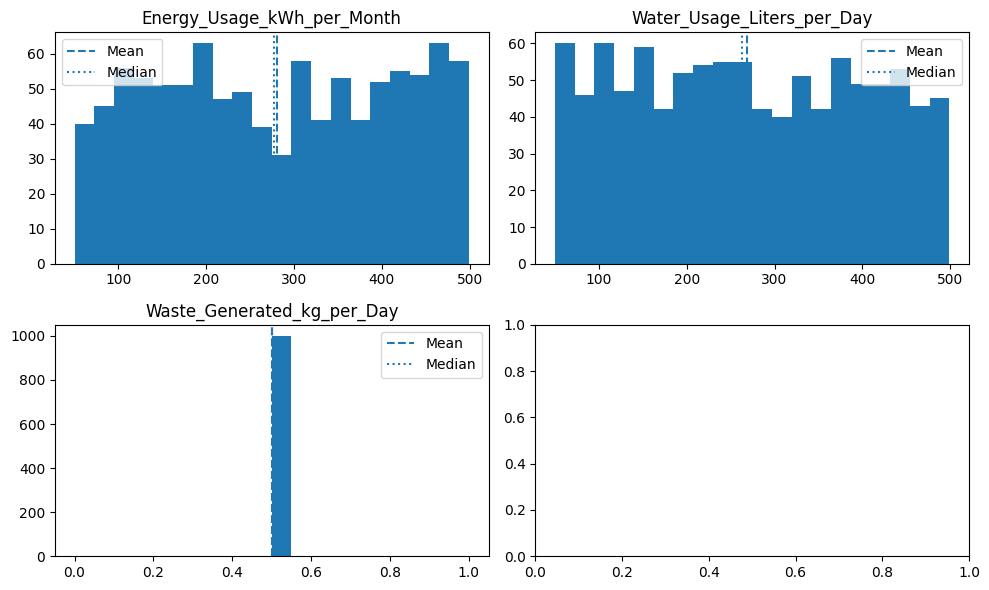

In [7]:
waste_col = 'Waste_Generated_kg_per_Day'
# Handle missing column: Add it with a default value if it doesn't exist
if waste_col not in df.columns:
    df[waste_col] = 0.5 # Default value if column is missing

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

plot_cols = [
    'Energy_Usage_kWh_per_Month',
    'Water_Usage_Liters_per_Day',
    'Waste_Generated_kg_per_Day'
]

for i, col in enumerate(plot_cols):
    ax = axes[i//2, i%2]
    ax.hist(df[col], bins=20)
    ax.axvline(df[col].mean(), linestyle='--', label='Mean')
    ax.axvline(df[col].median(), linestyle=':', label='Median')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()


## 3. Carbon Emission Formula (Energy + Water + Waste)

In [8]:
# emission factors
EF_ELECTRICITY = 0.82
EF_WATER = 0.0003
EF_WASTE = 0.5
EF_RECYCLED = 0.1

# Define waste_col and recycling_col for consistent use across the notebook
waste_col = 'Waste_Generated_kg_per_Day'
recycling_col = 'Recycling_Rate'

# Handle missing columns: Add them with default values if they don't exist
if waste_col not in df.columns:
    df[waste_col] = 0.5 # Default value if column is missing

if recycling_col not in df.columns:
    df[recycling_col] = 0.20 # Default value if column is missing

# Fill any NaNs in these columns after ensuring they exist
df[waste_col] = df[waste_col].fillna(df[waste_col].mean())
df[recycling_col] = df[recycling_col].fillna(df[recycling_col].mean())

# keep recycling between 0 and 1
df[recycling_col] = df[recycling_col].clip(0, 1)

# carbon calculations
df['Waste_Carbon'] = (
    df[waste_col] * 30 *
    ((1 - df[recycling_col]) * EF_WASTE + df[recycling_col] * EF_RECYCLED)
)

df['Energy_Carbon'] = df['Energy_Usage_kWh_per_Month'] * EF_ELECTRICITY

df['Water_Carbon'] = df['Water_Usage_Liters_per_Day'] * 30 * EF_WATER

df['Calculated_Carbon'] = (
    df['Energy_Carbon'] +
    df['Water_Carbon'] +
    df['Waste_Carbon']
)

4. Sustainability Score

In [9]:
# sustainability score (NOT direct formula)
df['Sustainability_Score'] = (
    100
    - 0.02 * df['Energy_Usage_kWh_per_Month']
    - 0.01 * df['Water_Usage_Liters_per_Day']
    - 0.5  * df['Waste_Generated_kg_per_Day']
    - 0.03 * df['Calculated_Carbon']
)

# add noise
df['Sustainability_Score'] += np.random.normal(0, 5, len(df))

# limit range
df['Sustainability_Score'] = df['Sustainability_Score'].clip(0, 100)

In [10]:
X = df[[
    'Energy_Usage_kWh_per_Month',
    'Water_Usage_Liters_per_Day',
    'Waste_Generated_kg_per_Day',
    'Calculated_Carbon'
]]

y = df['Sustainability_Score']



5. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


6. Models

In [12]:
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=50, max_depth=5)
xgb = XGBRegressor(n_estimators=50, max_depth=3)

7. Training

In [13]:

lr.fit(X_train_sc, y_train)
rf.fit(X_train_sc, y_train)
xgb.fit(X_train_sc, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

8. Prediction

In [14]:

lr_pred = lr.predict(X_test_sc)
rf_pred = rf.predict(X_test_sc)
xgb_pred = xgb.predict(X_test_sc)

ensemble_pred = (lr_pred + rf_pred + xgb_pred) / 3


9. comparison table

In [15]:

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Linear': lr_pred,
    'RF': rf_pred,
    'XGB': xgb_pred,
    'Ensemble': ensemble_pred
})

print("\nSample Predictions:")
print(comparison.head(10))


Sample Predictions:
      Actual     Linear         RF        XGB   Ensemble
0  72.195728  77.572979  77.159967  76.989601  77.240849
1  90.618008  90.355039  88.867949  89.212265  89.478418
2  69.035595  75.725608  76.297245  75.103691  75.708848
3  92.863033  79.298903  79.219362  79.958435  79.492233
4  84.463732  80.979782  79.709830  80.430344  80.373318
5  88.647700  94.940355  95.431820  95.552818  95.308331
6  84.344349  86.701352  87.911377  86.930870  87.181200
7  85.956348  92.691744  91.502286  92.474678  92.222903
8  81.912827  81.867226  81.511028  81.208168  81.528807
9  69.279715  78.355721  78.204001  76.835091  77.798271


10. Evaluation


In [17]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("R2:", round(r2_score(y_true, y_pred), 3))
    print("MAE:", round(mean_absolute_error(y_true, y_pred), 3))
    print("RMSE:", round(rmse(y_true, y_pred), 3))

evaluate("Linear", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, xgb_pred)
evaluate("Ensemble", y_test, ensemble_pred)



Linear
R2: 0.564
MAE: 4.012
RMSE: 5.037

Random Forest
R2: 0.573
MAE: 3.937
RMSE: 4.985

XGBoost
R2: 0.534
MAE: 4.164
RMSE: 5.209

Ensemble
R2: 0.567
MAE: 4.013
RMSE: 5.021


11. Visual: Actual vs Predicted

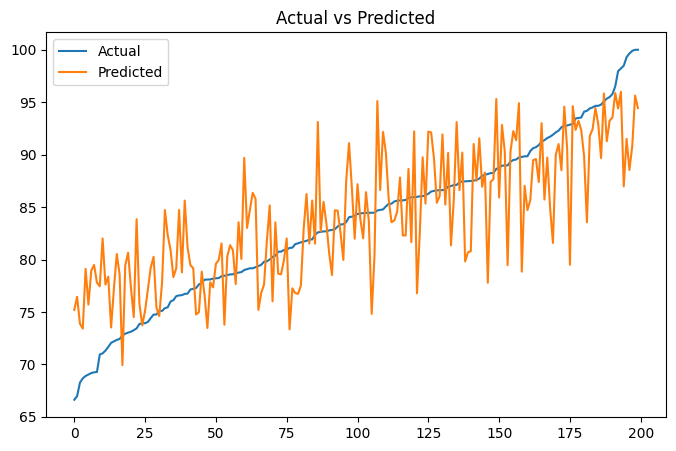

In [18]:
sorted_idx = y_test.values.argsort()

plt.figure(figsize=(8,5))

plt.plot(y_test.values[sorted_idx], label='Actual')
plt.plot(ensemble_pred[sorted_idx], label='Predicted')

plt.title("Actual vs Predicted")
plt.legend()
plt.show()

12. Learning Curve - Linear Regression

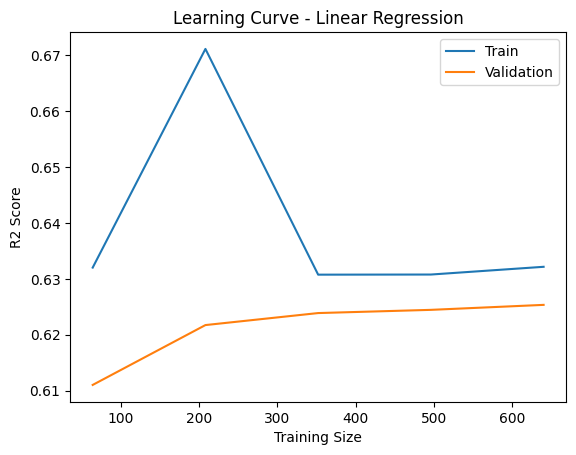

In [19]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

model = LinearRegression()

sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_sc,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure()
plt.plot(sizes, train_scores.mean(axis=1), label='Train')
plt.plot(sizes, val_scores.mean(axis=1), label='Validation')

plt.title("Learning Curve - Linear Regression")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.legend()

plt.show()

13. Learning Curve - RandomForestRegressor

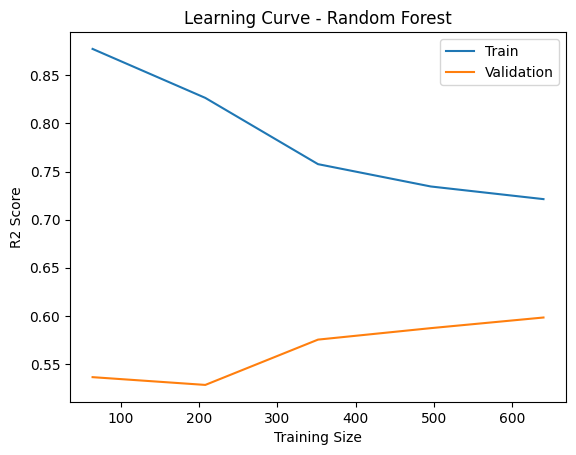

In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50, max_depth=5)

sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_sc,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure()
plt.plot(sizes, train_scores.mean(axis=1), label='Train')
plt.plot(sizes, val_scores.mean(axis=1), label='Validation')

plt.title("Learning Curve - Random Forest")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.legend()

plt.show()

14. Learning Curve - XGBoost

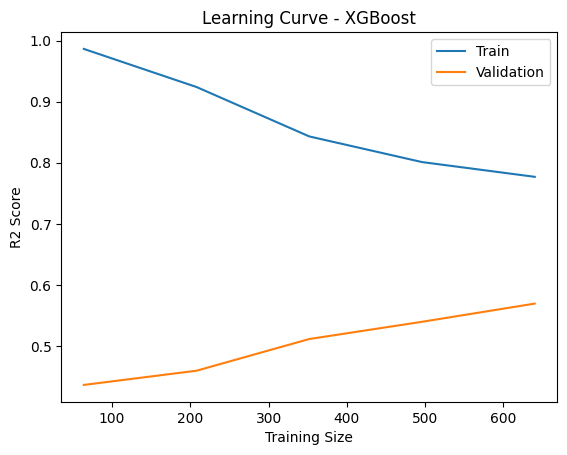

In [21]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=50, max_depth=3)

sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_sc,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure()
plt.plot(sizes, train_scores.mean(axis=1), label='Train')
plt.plot(sizes, val_scores.mean(axis=1), label='Validation')

plt.title("Learning Curve - XGBoost")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.legend()

plt.show()

15. Bias- Variance Tradeoff - Linear Regression

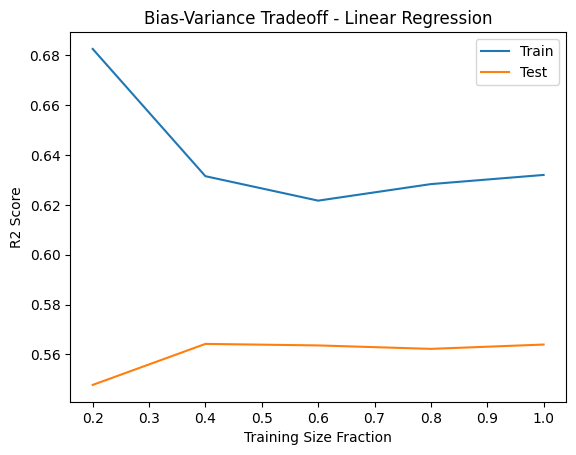

In [22]:
from sklearn.linear_model import LinearRegression
import numpy as np

sizes = np.linspace(0.2, 1.0, 5)

train_scores = []
test_scores = []

for s in sizes:
    n = int(len(X_train_sc) * s)

    model = LinearRegression()
    model.fit(X_train_sc[:n], y_train[:n])

    train_scores.append(r2_score(y_train[:n], model.predict(X_train_sc[:n])))
    test_scores.append(r2_score(y_test, model.predict(X_test_sc)))

plt.figure()
plt.plot(sizes, train_scores, label='Train')
plt.plot(sizes, test_scores, label='Test')

plt.title("Bias-Variance Tradeoff - Linear Regression")
plt.xlabel("Training Size Fraction")
plt.ylabel("R2 Score")
plt.legend()
plt.show()

16. Bias- Variance Tradeoff - Random Forest Regressor

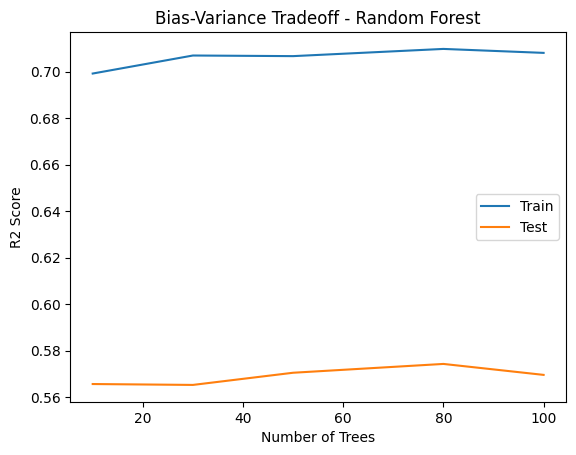

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

n_values = [10, 30, 50, 80, 100]

train_scores = []
test_scores = []

for n in n_values:
    model = RandomForestRegressor(n_estimators=n, max_depth=5)
    model.fit(X_train_sc, y_train)

    train_scores.append(r2_score(y_train, model.predict(X_train_sc)))
    test_scores.append(r2_score(y_test, model.predict(X_test_sc)))

plt.figure()
plt.plot(n_values, train_scores, label='Train')
plt.plot(n_values, test_scores, label='Test')

plt.title("Bias-Variance Tradeoff - Random Forest")
plt.xlabel("Number of Trees")
plt.ylabel("R2 Score")
plt.legend()
plt.show()

17. Bias- Variance Tradeoff - XGBoost

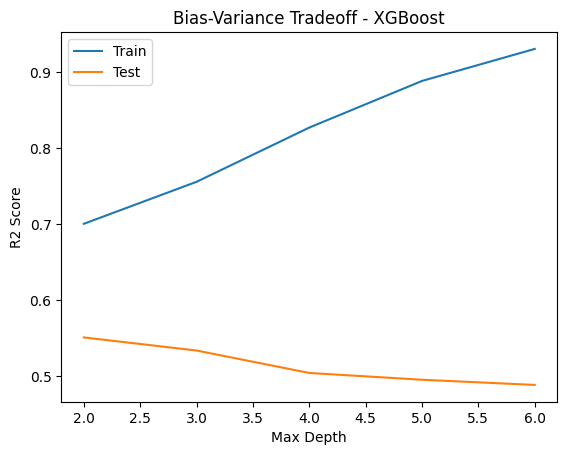

In [24]:
from xgboost import XGBRegressor

depth_values = [2, 3, 4, 5, 6]

train_scores = []
test_scores = []

for d in depth_values:
    model = XGBRegressor(n_estimators=50, max_depth=d)
    model.fit(X_train_sc, y_train)

    train_scores.append(r2_score(y_train, model.predict(X_train_sc)))
    test_scores.append(r2_score(y_test, model.predict(X_test_sc)))

plt.figure()
plt.plot(depth_values, train_scores, label='Train')
plt.plot(depth_values, test_scores, label='Test')

plt.title("Bias-Variance Tradeoff - XGBoost")
plt.xlabel("Max Depth")
plt.ylabel("R2 Score")
plt.legend()
plt.show()

18.Time-Series Forecasting

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


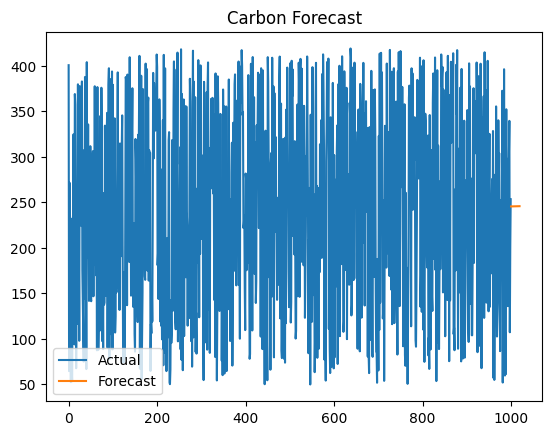

In [25]:
df['Time'] = np.arange(len(df))
X_time = df[['Time']]
y_time = df['Calculated_Carbon']

ts_model = LinearRegression()
ts_model.fit(X_time, y_time)

future_time = np.arange(len(df), len(df)+20).reshape(-1,1)
forecast = ts_model.predict(future_time)

plt.plot(df['Time'], y_time, label='Actual')
plt.plot(future_time, forecast, label='Forecast')
plt.title("Carbon Forecast")
plt.legend()
plt.show()

19. Optimization Model

Baseline Carbon: 239.66
Optimized Carbon: 142.81
Reduction (%): 40.41

Optimal Values:
Energy: 168.11
Water : 134.12
Waste : 0.25


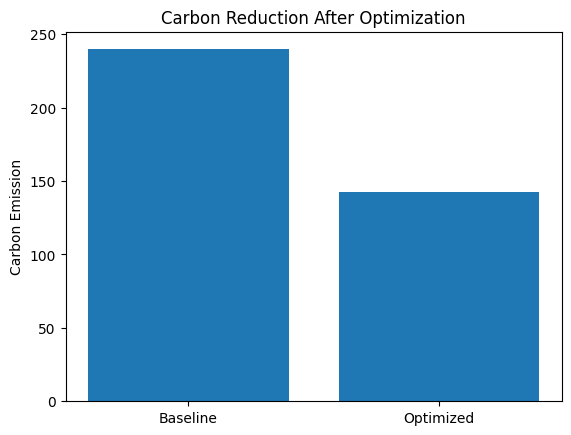

In [26]:
avg_energy = df["Energy_Usage_kWh_per_Month"].mean()
avg_water  = df["Water_Usage_Liters_per_Day"].mean()
avg_waste  = df["Waste_Generated_kg_per_Day"].mean()

# Objective Function (Minimize Carbon)
def carbon_objective(x):
    energy, water, waste = x

    carbon = (
        energy * EF_ELECTRICITY +
        water * 30 * EF_WATER +
        waste * 30 * EF_WASTE
    )

    return carbon

# Constraints (Realistic limits)
constraints = [
    {'type': 'ineq', 'fun': lambda x: x[0] - 0.6 * avg_energy},   # energy not too low
    {'type': 'ineq', 'fun': lambda x: x[1] - 0.5 * avg_water},    # water constraint
    {'type': 'ineq', 'fun': lambda x: x[2] - 0.5 * avg_waste}     # waste constraint
]

# Bounds (real-world limits)
bounds = [
    (0.5 * avg_energy, 1.2 * avg_energy),
    (0.5 * avg_water,  1.2 * avg_water),
    (0.5 * avg_waste,  1.5 * avg_waste)
]

# Initial Guess
x0 = [avg_energy, avg_water, avg_waste]

# Optimization
result = minimize(carbon_objective, x0, method='SLSQP',
                  bounds=bounds, constraints=constraints)

# Results
baseline = carbon_objective(x0)
optimized = carbon_objective(result.x)

print("Baseline Carbon:", round(baseline, 2))
print("Optimized Carbon:", round(optimized, 2))
print("Reduction (%):", round((baseline - optimized)/baseline * 100, 2))

print("\nOptimal Values:")
print("Energy:", round(result.x[0], 2))
print("Water :", round(result.x[1], 2))
print("Waste :", round(result.x[2], 2))

# Visualization
plt.figure()

plt.bar(["Baseline", "Optimized"], [baseline, optimized])

plt.title("Carbon Reduction After Optimization")
plt.ylabel("Carbon Emission")

plt.show()

20. SUGGESTION SYSTEM

In [27]:
def suggest(row):
    suggestions = []

    # energy
    if row['Energy_Usage_kWh_per_Month'] > df['Energy_Usage_kWh_per_Month'].mean():
        suggestions.append("Reduce electricity usage")

    # water
    if row['Water_Usage_Liters_per_Day'] > df['Water_Usage_Liters_per_Day'].mean():
        suggestions.append("Reduce water consumption")

    # waste
    if row['Waste_Generated_kg_per_Day'] > df['Waste_Generated_kg_per_Day'].mean():
        suggestions.append("Improve waste management")

    # recycling
    if row['Recycling_Rate'] < df['Recycling_Rate'].mean():
        suggestions.append("Increase recycling rate")

    # if everything is good
    if len(suggestions) == 0:
        return "Good sustainability performance"

    return ", ".join(suggestions)


# apply function
df['Suggestion'] = df.apply(suggest, axis=1)

# display result
print("\nSample Suggestions:")
print(df[[
    'Energy_Usage_kWh_per_Month',
    'Water_Usage_Liters_per_Day',
    'Waste_Generated_kg_per_Day',
    'Recycling_Rate',
    'Suggestion'
]].head())


Sample Suggestions:
   Energy_Usage_kWh_per_Month  Water_Usage_Liters_per_Day  \
0                         478                         277   
1                          69                         151   
2                         322                         124   
3                         168                         466   
4                         120                         495   

   Waste_Generated_kg_per_Day  Recycling_Rate  \
0                         0.5             0.2   
1                         0.5             0.2   
2                         0.5             0.2   
3                         0.5             0.2   
4                         0.5             0.2   

                                          Suggestion  
0  Reduce electricity usage, Reduce water consump...  
1                            Increase recycling rate  
2  Reduce electricity usage, Increase recycling rate  
3  Reduce water consumption, Increase recycling rate  
4  Reduce water consumption, Increase recy